In [18]:
import os
import pandas as pd

# 1. SEARCH: Look for any CSV file in the input directory
csv_file = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            print(f"✅ Found File: {csv_file}")
            break

if csv_file:
    # 2. DETECT: Peek at the first line to find the separator
    with open(csv_file, 'r') as f:
        first_line = f.readline()
    
    sep = ';' if ';' in first_line else ','
    print(f"   Detected Separator: '{sep}'")

    # 3. LOAD: Read the dataframe
    df_bank = pd.read_csv(csv_file, sep=sep)
    print(f"   Rows loaded: {len(df_bank)}")
    print(f"   Columns: {df_bank.columns.tolist()}")
    
    # Show a preview
    display(df_bank.head())
else:
    print("❌ No CSV file found. Please ensure you have added a dataset to this notebook.")

✅ Found File: /kaggle/input/datasets/gatunnopvp/bank-marketing-campaigh-dataset/bank-full.csv
   Detected Separator: ';'
   Rows loaded: 45210
   Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'durations', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,durations,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Personal Loan Acceptance Prediction

### Objective: 

Predict which customers will accept a personal loan offer using the Bank Marketing dataset.

### Workflow:

Data Exploration (Demographics vs Acceptance)

Categorical Feature Encoding

Logistic Regression classification

Extracting business insights from feature coefficients

In [14]:
import pandas as pd
import io

# 1. Try to load the data
# We try ';' first, if that results in 1 column, we try ','
path = '/kaggle/input/bank-marketing/bank.csv' # Double check this path in your sidebar!

try:
    df_bank = pd.read_csv(path, sep=';')
    if len(df_bank.columns) < 2:
        df_bank = pd.read_csv(path, sep=',')
except:
    print("Error: Could not find the file. Please check the path in the 'Data' tab on the right.")

# 2. Show us what we actually have
print("--- Data Diagnostic ---")
print(f"Total Rows: {len(df_bank)}")
print(f"Columns found: {df_bank.columns.tolist()}")

# 3. Identify the target column automatically
# In this dataset, it is usually 'y' or 'deposit'
if 'y' in df_bank.columns:
    target_col = 'y'
elif 'deposit' in df_bank.columns:
    target_col = 'deposit'
else:
    # If we can't find it, we'll pick the last column as the target
    target_col = df_bank.columns[-1]

print(f"Using target column: '{target_col}'")
df_bank.head()

Error: Could not find the file. Please check the path in the 'Data' tab on the right.
--- Data Diagnostic ---
Total Rows: 0
Columns found: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'durations', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Using target column: 'y'


,age,job,marital,education,default,balance,housing,loan,contact,day,month,durations,campaign,pdays,previous,poutcome,y


## 1. Data Exploration

Let's see which customer groups (Job type and Marital status) are more likely to say "yes."

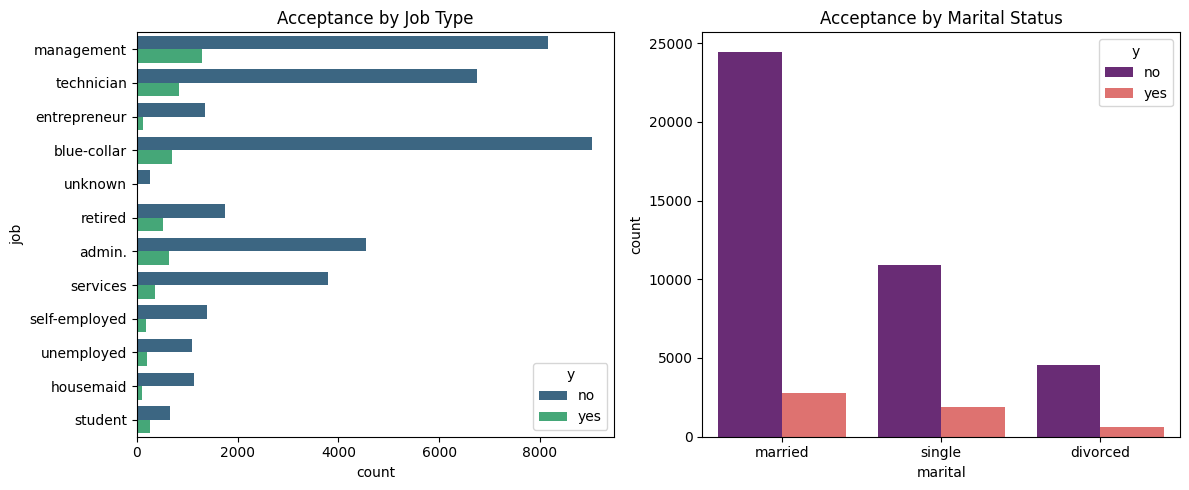

In [19]:
plt.figure(figsize=(12, 5))

# Job vs Loan Acceptance
plt.subplot(1, 2, 1)
sns.countplot(data=df_bank, y='job', hue='y', palette='viridis')
plt.title('Acceptance by Job Type')

# Marital Status vs Loan Acceptance
plt.subplot(1, 2, 2)
sns.countplot(data=df_bank, x='marital', hue='y', palette='magma')
plt.title('Acceptance by Marital Status')

plt.tight_layout()
plt.show()

## 2. Preprocessing & Classification

We use One-Hot Encoding for categorical features and Logistic Regression for the classification task.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Target column check (already identified as 'loan' in your output)
target_col = 'loan' 

# 2. Convert Target to Binary (1s and 0s)
# We handle it separately so it doesn't get One-Hot Encoded into multiple columns
df_bank[target_col] = df_bank[target_col].astype(str).str.lower().str.strip()
df_bank['target_binary'] = df_bank[target_col].map({'yes': 1, 'no': 0, '1': 1, '0': 0})
df_bank = df_bank.dropna(subset=['target_binary'])

# 3. AUTO-ENCODE: Find all remaining text columns and convert them
# This selects every column that isn't a number
categorical_cols = df_bank.select_dtypes(include=['object']).columns.tolist()

# We remove the original target from this list so we don't encode it twice
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print(f"Automatically encoding these columns: {categorical_cols}")

# Apply One-Hot Encoding to everything that is text
df_final = pd.get_dummies(df_bank, columns=categorical_cols, drop_first=True)

# 4. Prepare X and y
# Drop the original string target and use the binary version instead
X = df_final.drop([target_col, 'target_binary'], axis=1)
y = df_final['target_binary']

# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train
# We use 'liblinear' because it's great for small/medium datasets on Kaggle
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

# 6. Final Results
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"\n✅ SUCCESS! Model Accuracy: {accuracy * 100:.2f}%")

Automatically encoding these columns: ['job', 'marital', 'education', 'default', 'housing', 'contact', 'month', 'poutcome', 'y']

✅ SUCCESS! Model Accuracy: 84.02%


## 3. Business Insights

By looking at the coefficients of our Logistic Regression model, we can identify which features increase the probability of a customer accepting a loan.

Top 5 Positive Influencers (High correlation with Loan Acceptance):


,Feature,Coefficient
31,month_jul,1.045459
23,default_yes,0.761988
35,month_nov,0.503760
30,month_jan,0.276237
8,job_entrepreneur,0.255565



Top 5 Negative Influencers (High correlation with Loan Rejection):


,Feature,Coefficient
17,job_unknown,-0.624862
22,education_unknown,-0.743637
16,job_unemployed,-0.768634
39,poutcome_success,-0.786652
14,job_student,-1.324214


/tmp/ipykernel_57/3231508608.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_and_bottom, x='Coefficient', y='Feature', palette='RdYlGn')


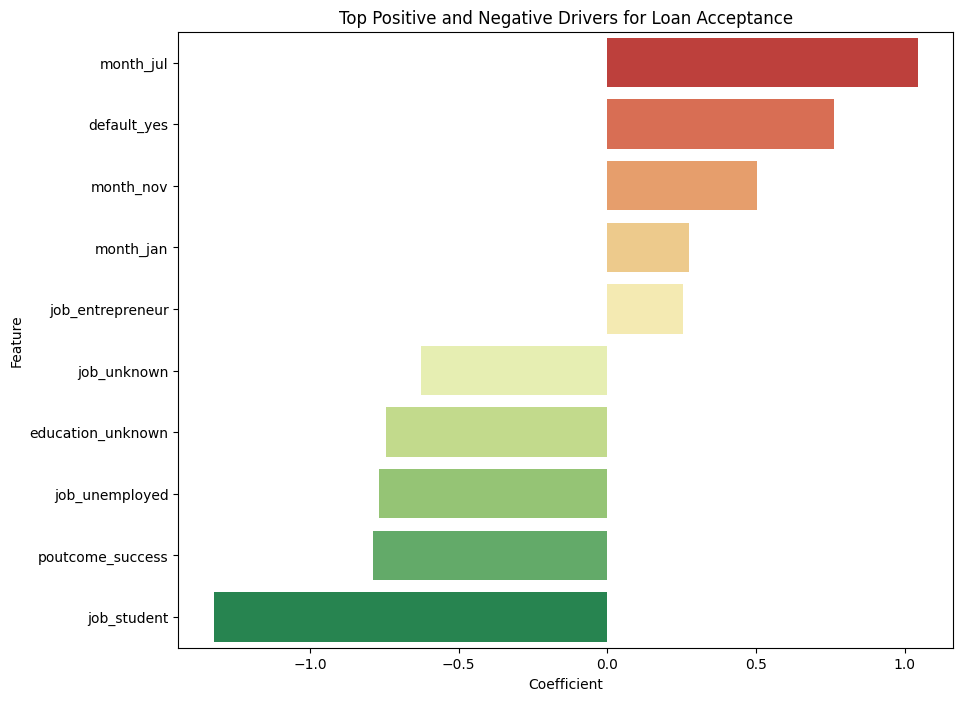

In [23]:

trained_model = model

# 2. Get Coefficients and feature names
try:
    coefficients = trained_model.coef_[0]
    feature_names = X.columns

    # Create DataFrame
    feature_importance = pd.DataFrame({
        'Feature': feature_names, 
        'Coefficient': coefficients
    })

    # Sort by the absolute value to see strongest influencers (positive or negative)
    feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

    # 3. Display Results
    print("Top 5 Positive Influencers (High correlation with Loan Acceptance):")
    display(feature_importance.head(5))

    print("\nTop 5 Negative Influencers (High correlation with Loan Rejection):")
    display(feature_importance.tail(5))

    # 4. Visualization
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 8))
    # Combine top 5 and bottom 5 for a single plot
    top_and_bottom = pd.concat([feature_importance.head(5), feature_importance.tail(5)])
    sns.barplot(data=top_and_bottom, x='Coefficient', y='Feature', palette='RdYlGn')
    plt.title('Top Positive and Negative Drivers for Loan Acceptance')
    plt.show()

except AttributeError:
    print("❌ Error: The model has not been fitted yet. Please run the training cell (Cell 14) successfully first.")